# Lecture 2: Continous Time Markov Chains

In today's lecture we are going the different method to study and analyse the Continous Time Markov Chains (CTMC). We are going also to recover the logistic scenario of the previous time and try to simulate it correctly using CTMCs. In today lecture we are going to *scipy.integrate* to solve some differential equations, however we will use only for this lecture while in the next time we will do it ourselves. 

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import random
import scipy.integrate as deqsol

## Exercise 1: Finite system with random rates

As first exercise, we will start, as for the DTMC, with a system able to have a finite number of states. In particular:

<em>Let's suppose to have a system that can stay in one of 5 possible states namely $[0,1,2,3,4]$. The transition rates, needed to compute the infinitesimal generator, have to be randomly computed first and the matrix have to be adapted according to these. We want to compute the probability of being in each state given an initial probability distribution $p_0$ after a certain time $T$.</em>

Having a finite number of states, we can simulate this using some projections of probability as we have done with the DTMC. In fact, given a finite number of states and constant rates, we can compute for a CTMC the probability at a certain time instant $T$ starting from the initial probability distribution and the infinitesimal generator. This can be done using the so-called *Forward Kolmogorov Equation*:

$$
\frac{dP(t)}{dt}=P(t)Q \qquad\Rightarrow\qquad P(t)=p_0\exp(Qt)
$$

In most of the case this expression can be treated using the Jordan-Chevalley decomposition or using the transformation to the diagonal form (do you know how to do it?). Otherwise, numerically, this system is a typical system of ODEs thus we can solve it using traditional methods for differential equation. This time we will use *scipy.integrate* with its *odeint* method for simplicity. This actually work as an improved RK4 method.

As first thing we have to create the class:

In [2]:
class CTMC(object):

    #Generating randomly a generator, but leaving the possibility of pass it,
    #we need to implement a method to check the properties.
    @staticmethod
    def generator_check(M: np.matrix)->None:
        '''
        This method will check if the given generator
        is valid or not.
        '''

        #Let's check first if it's 2D
        if(M.ndim!=2):
            raise RuntimeError("The infinitesimal generator have to be 2D")

        #2. Check if it's a squared matrix
        if(np.shape(M)[0]!=np.shape(M)[1]):
            raise RuntimeError("Number of rows is different from the number of columns")

        #3. Check if the out of diagonal coefficient are positive and if the row sum up to zero
        #NOTE: with the positivity request is equivalent to ask the sum up to the diagonal coeff.
        for i in range(np.shape(M)[0]):
            s = 0
            for j in range(np.shape(M)[1]):
                if(M[i,j]<0 and i!=j): #Out of diagonal
                    print(i,j)
                    raise RuntimeError("The infinitesimal generator has a negative entry")
                s=s+M[i,j]
            if(s>0.0000001): #Row sum up
                print(i)
                raise RuntimeError("The infinitesimal generator has a row that does not sum up to 0")

        return

    #Now we create a method that produce the infinitesimal generator.
    #Luckly we are no more working with probabilities thus we can have any positive
    #number as a rate...
    def __infinitesimal_generator_maker(self)->np.matrix:
        '''
        This function will make the infinitesimal generator
        for our problem.
        '''
        Q = np.zeros((self.n_states,self.n_states),dtype=float)

        for i in range(self.n_states):
            s = 0.0
            for j in range(self.n_states): #Generate each rate in the row
                if(i!=j):
                    Q[i,j] = random.random()
                    s += Q[i,j]
            Q[i,i] = -1.0*s #The self rate is -sum_of_the_other

        return Q

    #CONSTRUCTOR
    def __init__(self,N: int)->None:
        self.n_states= N
        self.inf_generator = self.__infinitesimal_generator_maker()
        self.generator_check(self.inf_generator)
        return

In [3]:
chain = CTMC(5)
print(chain.inf_generator)

[[-1.74542449  0.19663867  0.47822017  0.58767481  0.48289084]
 [ 0.24747661 -1.8097726   0.1034301   0.93731203  0.52155386]
 [ 0.88269034  0.03837103 -1.77657765  0.6489297   0.20658657]
 [ 0.2088001   0.58663436  0.77556838 -2.51779997  0.94679714]
 [ 0.11111751  0.2924282   0.91832031  0.12649841 -1.44836443]]


Now we can solve the Kolmogorov equations using the solver and in this way compute the probability distribution given $p_0$ at a certain time $T$. To do this we will expand the class above

In [4]:
class CTMC(object):

    #Generating randomly a generator, but leaving the possibility of pass it,
    #we need to implement a method to check the properties.
    @staticmethod
    def generator_check(M: np.matrix)->None:
        '''
        This method will check if the given generator
        is valid or not.
        '''

        #Let's check first if it's 2D
        if(M.ndim!=2):
            raise RuntimeError("The infinitesimal generator have to be 2D")

        #2. Check if it's a squared matrix
        if(np.shape(M)[0]!=np.shape(M)[1]):
            raise RuntimeError("Number of rows is different from the number of columns")

        #3. Check if the out of diagonal coefficient are positive and if the row sum up to zero
        #NOTE: with the positivity request is equivalent to ask the sum up to the diagonal coeff.
        for i in range(np.shape(M)[0]):
            s = 0
            for j in range(np.shape(M)[1]):
                if(M[i,j]<0 and i!=j): #Out of diagonal
                    print(i,j)
                    raise RuntimeError("The infinitesimal generator has a negative entry")
                s=s+M[i,j]
            if(s>0.0000001): #Row sum up
                print(i)
                raise RuntimeError("The infinitesimal generator has a row that does not sum up to 0")

        return

    #Now we create a method that produce the infinitesimal generator.
    #Luckly we are no more working with probabilities thus we can have any positive
    #number as a rate...
    def __infinitesimal_generator_maker(self)->np.matrix:
        '''
        This function will make the infinitesimal generator
        for our problem.
        '''
        Q = np.zeros((self.n_states,self.n_states),dtype=float)

        for i in range(self.n_states):
            s = 0.0
            for j in range(self.n_states): #Generate each rate in the row
                if(i!=j):
                    Q[i,j] = random.random()
                    s += Q[i,j]
            Q[i,i] = -1.0*s #The self rate is -sum_of_the_other

        return Q

    #To solve we will use deqsol.odeint. This requuire a certain shape
    #for the field thus we will define it on fly inside here using the
    #required "grammar"
    def Kolmogorov_solve(self,p0: np.array,T: float,M: int)->np.array:
        '''
        Given the initial probabiity distribution and the time T
        This function will compute the probability array after
        T seconds a partition of M steps
        '''
        p = np.array(self.n_states,dtype=float)
    
        #define the system
        def system(y,t):
            p = y
            dydt = np.dot(p,self.inf_generator)
            return dydt
    
        t = np.linspace(0,T,M)
    
        sol = deqsol.odeint(system,p0,t) #compute the results
    
        return sol #The solution has also all the intermediate steps

    #CONSTRUCTOR
    def __init__(self,N: int)->None:
        self.n_states= N
        self.inf_generator = self.__infinitesimal_generator_maker()
        self.generator_check(self.inf_generator)
        return

In [5]:
chain = CTMC(5)
p0 = np.array([0.2,0.2,0.2,0.2,0.2])

trajs = chain.Kolmogorov_solve(p0,50.0,40)

print(trajs[-1,:])

[0.20358572 0.15040023 0.17848434 0.23655535 0.23097436]


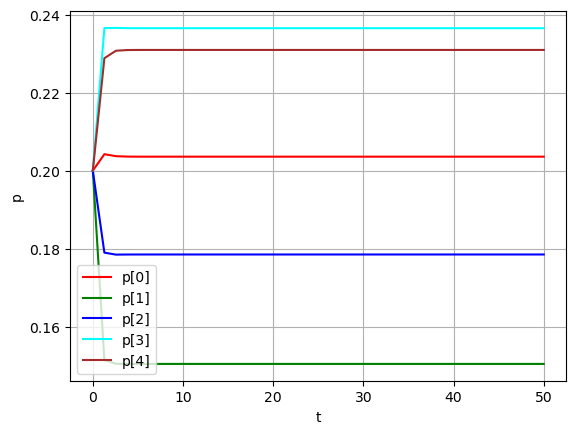

In [6]:
t = np.linspace(0,50.0,40)
plt.plot(t, trajs[:, 0], 'r', label='p[0]')
plt.plot(t, trajs[:, 1], 'g', label='p[1]')
plt.plot(t, trajs[:, 2], 'b', label='p[2]')
plt.plot(t, trajs[:, 3], 'cyan', label='p[3]')
plt.plot(t, trajs[:, 4], 'brown', label='p[4]')
plt.legend(loc='best')
plt.xlabel('t')
plt.ylabel('p')
plt.grid()
plt.show()

As we can observe such composed system, converge towards an invariant measure with no 0 states for the system in only a few iterations. This is obviously due to the complete connection property of our system that prevents the presence of some sort of absorbent states. 

## Exercise 2: Unlimited number of states

As before, the method using the Forward Kolmogorov Equation has some downsides. First of all we can have only a finite number of states thus we cannot treat problems that can have a huge plethora of values (also because, even trying to make it finite will increase too much the number of variables and the size of the matrix). Secondly, the Forward Equation depends on the infinitesimal generator $Q$ if this is not constant we will lose the ability to solve it analytically and, if it is not dependent only by $P(t)$ (which is extremely rare), also using ODEs.

Therefore, if we want to try to solve our good old problem of the Malthusian unbounded system, we cannot use the Forward Kolmogorov Equation to do it. Fortunately, the *trajectory sampling* comes to our rescue. To simulate CTMC realizations there are several method but two are the most common ones: the *Gillespie-SSA algorithm* and the *tau-leaping* (that is a variation of the first one). The first one is only formally correct one and able theoretically to produce *true* realization for our system. The *tau-leaping* is an approximation that tries to recall the CTMC back to an equivalent DTMC. Being an approximation it implements some errors but it is far less expensive under the simulative resources.

The CTMC in our course are quite a side topic thus we will look in this lectures how to simulate trajectories for a CTMC via Gillespie. Let's suppose for now to still have an infinitesimal generator. In this case, the algorithm is fairly simple:

0. We need at first to compute the Jump Matrix. This can be obtained from the infinitesimal generator and gives contains the probability to have a transition from the current state of the system to another. It is obtained normalizing on the the $-Q(i,i)$ and then setting to 0 the diagonal value. This must be done at every time step if $Q$ is time dependent.
1. Given the state of the trajectory at the time $t$, we need to compute what transition will occur. We need to generate a random number and see, using the probs of the Jump matrix, which state will be the next one.
2. Decided the state, we can obtain the time step length knowing that the time is exponentially distributed as opposite of the sum of the rates. The time step can be obtained from a uniform random number via reversing the exponential distribution formula:

$$
\delta t= -\log(1-r)/q_{tot} \qquad \text{where} \qquad r\sim Unif(0,1)
$$

In [7]:
random.seed(123456)

In [8]:
#AS ALWAYS LET'S PRODUCE A CLASS STARTING FROM THE BASE SEEN BEFORE

class CTMC_SIM(object):
    '''
    Continuous-Time Markov Chain Class
    based on a simulative approach.
    '''

    @staticmethod
    def generator_check(M: np.matrix)->None:
        '''
        This method will check if the given generator
        is valid or not.
        '''

        #Let's check first if it's 2D
        if(M.ndim!=2):
            raise RuntimeError("The infinitesimal generator have to be 2D")

        #2. Check if it's a squared matrix
        if(np.shape(M)[0]!=np.shape(M)[1]):
            raise RuntimeError("Number of rows is different from the number of columns")

        #3. Check if the out of diagonal coefficient are positive and if the row sum up to zero
        #NOTE: with the positivity request is equivalent to ask the sum up to the diagonal coeff.
        for i in range(np.shape(M)[0]):
            s = 0
            for j in range(np.shape(M)[1]):
                if(M[i,j]<0 and i!=j): #Out of diagonal
                    print(i,j)
                    raise RuntimeError("The infinitesimal generator has a negative entry")
                s=s+M[i,j]
            if(s>0.0000001): #Row sum up
                print(i)
                raise RuntimeError("The infinitesimal generator has a row that does not sum up to 0")

        return

    @staticmethod
    def jump_chain_mat_generator(Q: np.matrix)->np.matrix:
        '''
        This function will take a supposed valid
        infinitesimal generator and will produce
        the transition matrix for the associated
        jump chain.
        '''

        n = np.shape(Q)[0]
        J = np.zeros((n,n),dtype=float)

        for i in range(n):
            a = -Q[i,i]
            for j in range(n):
                if(i!=j):
                    J[i,j]=Q[i,j]/a

            J[i,i]=0

        return J

    @staticmethod
    def exp_time(l: float)->float:
        '''
        Given the rate, this function will generate a random time
        exponentially distributed
        '''
        r = random.random()
        n = -np.log(1-r)/l

        return n

    def __infinitesimal_generator_maker(self)->np.matrix:
        '''
        This function will make the infinitesimal generator
        for our problem.
        '''
        Q = np.zeros((self.n_states,self.n_states),dtype=float)

        for i in range(self.n_states):
            s = 0.0
            for j in range(self.n_states):
                if(i!=j):
                    Q[i,j] = random.random()
                    s += Q[i,j]
            Q[i,i] = -1.0*s

        return Q

    #COMPUTE CUMULATIVE PROBABILITY ARRAY
    def __cumulativeTransformer(self,p0:np.array)->np.array:
        '''
        Given a probability array this function will compute
        the cumulative of such distribution.
        '''
        p = np.zeros(len(p0),dtype=float)
        p[0] = p0[0]

        for i in range(1,len(p)):
            p[i] = p0[i] + p[i-1]
        
        return p

    #STATE COMPUTATION
    def __obtainState(self,p0:np.array)->int:
        '''
        Given a probability distribution of the state this function will
        produce a weighted random state.
        '''
        p = self.__cumulativeTransformer(p0)

        r = random.random()
        s = 0
        
        for i in range(len(p0)):
            if((r<p[i]) and (abs(p[i]-p[i-1])>0.0000001)):
                s = i
                break
        return s

    def __simulationSSA(self,p0: np.array,T: float)->int:
        '''
        This function will use the Gillespie-SSA algorithm
        to produce a stochastic trajectory for the CTCM
        '''
        #First thing we need to do is to obtain the transition mat of the jump chain
        P = self.jump_chain_mat

        #Simulate the trajectory
        state_0 = self.__obtainState(p0) #generate the initial state
        time = 0.0 #initialize time

        while(time<T):
            state_1 = self.__obtainState(P[state_0,:])
            time = time + self.exp_time(-self.inf_generator[state_0,state_0])
            if(time<T):
                state_0 = state_1

        return state_0

    def compute_prob_dist(self,p0:np.array,T: float,Nsim: int)->np.array:
        '''
        Given the initial distribution this function will produce
        the distribution after time T using Nsim simulations
        '''
        #if T=0 no projections have to be made
        if(T==0):
            return p0
    
        #if T is negative it as no sense 
        if(T<0):
            raise RuntimeError("Negative time for forward prediction")

        #Check Nsim
        if(Nsim<=0):
            raise RuntimeError("Non positive number of simulations")
    
        #Create the bins vector
        bins = np.zeros(self.n_states,dtype=float)
        
        for i in range(Nsim):
            s = self.__simulationSSA(p0,T) #simulate a CTMC's traj
            bins[s] += 1.0

        #Normalization
        bins = bins/Nsim
        
        return bins
        

    #CONSTRUCTOR
    def __init__(self,N: int)->None:
        self.n_states= N
        self.inf_generator = self.__infinitesimal_generator_maker()
        self.generator_check(self.inf_generator)
        self.jump_chain_mat = self.jump_chain_mat_generator(self.inf_generator)
        return

In [9]:
chain = CTMC_SIM(5)
p0 = np.array([0.2,0.2,0.2,0.2,0.2])

p_out = chain.compute_prob_dist(p0,50.0,10000)

print(p_out)

[0.0437 0.3373 0.3747 0.1319 0.1124]


<BarContainer object of 5 artists>

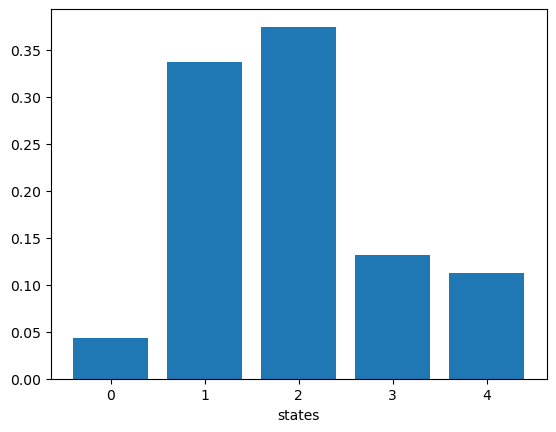

In [10]:
x = np.linspace(0,len(p_out)-1,len(p_out))

plt.xlabel("states")

plt.bar(x,p_out)

Kanpeki! It works well. Now we need to adapt it to our logistic problem where the state space has not a fixed dimensionality. Let's suppose that in every time window the system is able to do only transitions from the $N$ size to the $N+1$ and $N-1$ size. This is actually not mandatory and it is easy to generalize to other transitions. Given a certain population size $N$ we have the probability to move to $N+1$ and $N-1$ with rates $\lambda$ and $\mu$.

In [11]:
class MALT_SIM(object):
    '''
    Continuous-Time Markov Chain Class
    based on a simulative approach to
    simulate a Malthusian system.
    '''

    @staticmethod
    def exp_time(l: float)->float:
        '''
        Given the rate, this function will generate a random time
        exponentially distributed
        '''
        r = random.random()
        n = -np.log(1-r)/l

        return n

    #COMPUTE CUMULATIVE PROBABILITY ARRAY
    def __cumulativeTransformer(self,p0:np.array)->np.array:
        '''
        Given a probability array this function will compute
        the cumulative of such distribution.
        '''
        p = np.zeros(len(p0),dtype=float)
        p[0] = p0[0]

        for i in range(1,len(p)):
            p[i] = p0[i] + p[i-1]
        
        return p

    #INITIAL STATE COMPUTATION
    def __obtainState(self,p0:np.array)->int:
        '''
        Given a probability distribution of the state this function will
        produce a weighted random state.
        '''
        p = self.__cumulativeTransformer(p0)

        r = random.random()
        s = 0
        
        for i in range(len(p0)):
            if((r<p[i]) and (abs(p[i]-p[i-1])>0.0000001)):
                s = i
                break
        return s

    #INTERMEDIATE STATE COMPUTATION
    def __computeNewState(self,s0: int)->int:
        '''
        Given the actual state of the CTMC, this
        function will return the new state of the
        CTMC according to the Malthusian rates.
        '''
        r = random.random()
        prob_b = self._b/(self._b+self._d)
        #prob_d = self._d/(self._b+self._d) #It is not need due to complementary
        
        if(r<prob_b or s0<=0):
            return s0+1
        else:
            return s0-1
        

    def __simulationSSA(self,p0: np.array,T: float)->int:
        '''
        This function will use the Gillespie-SSA algorithm
        to produce a stochastic trajectory for the CTCM
        '''
        #Simulate the trajectory
        state_0 = self.__obtainState(p0) #generate the initial state
        time = 0.0 #initialize time

        while(time<T):
            state_1 = self.__computeNewState(state_0)
            time = time + self.exp_time((self._b+self._d))
            if(time<T):
                state_0 = state_1

        return state_0

    def compute_prob_dist(self,p0:np.array,T: float,Nsim: int)->np.array:
        '''
        Given the initial distribution this function will produce
        the distribution after time T using Nsim simulations
        '''
        #if T=0 no projections have to be made
        if(T==0):
            return p0
    
        #if T is negative it as no sense 
        if(T<0):
            raise RuntimeError("Negative time for forward prediction")

        #Check Nsim
        if(Nsim<=0):
            raise RuntimeError("Non positive number of simulations")

        #THIS TIME WE NEED TO FIND THE MAXIMUM VALUE TO DO THE DISTRIBUTION
        states = np.zeros(Nsim,dtype=int)
        
        for i in range(Nsim):
            states[i] = self.__simulationSSA(p0,T) #simulate a CTMC's traj

        s_max = np.max(states)

        bins = np.zeros(s_max+1,dtype=int)

        for i in range(Nsim):
            bins[states[i]]+=1

        #Normalization
        bins = bins/Nsim
        
        return bins
        

    #CONSTRUCTOR
    def __init__(self,b: float,d: float)->None:
        if(b<=0 or d<=0):
            raise RuntimeError("The parameters of the CTMC must be positive.")
        
        self._b = b
        self._d = d
        return

Now we can try to simulate

In [12]:
system = MALT_SIM(2.5,2.0)

p0=np.array([0,0,0,0,1.0])

bins = system.compute_prob_dist(p0,25,1000)

<BarContainer object of 50 artists>

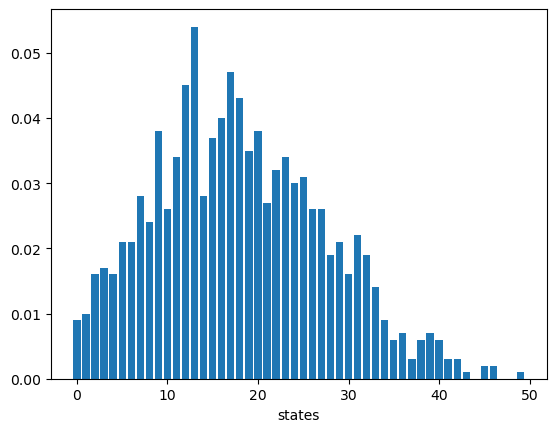

In [13]:
x = np.linspace(0,len(bins)-1,len(bins))

plt.xlabel("states")

plt.bar(x,bins)

As we can notice we are able to obtain a good distribution using the trajectory sampling

**NOTE**: once again, why are we doing this? Why we are opting to describe this situations with a CTMC instead of SDE? In fact we have seen that the SDE are both easier to use and have also a lot of improved charateristics such as the possibility of finding the attractors and so on. The main reason resides in the hypothesis needed to use the SDE...

## Exercise 3: Chemical Reaction Networks

There are several useful applications of the CTMC other than the usage for small size populations. Nonetheless, most of this scenario shares the necessity to have a discretization of the population to model and keep in consideration some propeties that are not described by continous version. One of the most common application of this are the Chemical Reaction Networks (CRN) which are used to described chemical reactions and other phenomena that behaves in a similar way (e.g. Disease Spreading, Compartimental Problems,...).

In this exercise, we will consider one example of CRN with three classes of elements that reacts one each other according to this reactions:

$$
\emptyset \rightarrow_{k_1} A \qquad A \rightarrow_{k_2} B \qquad A+B \rightarrow_{k_3} C \qquad A \rightarrow_{\mu} \emptyset \qquad C \rightarrow_{\nu} \emptyset
$$

Thus in this situtation we have three classes thus we cannot simply keep the evolution sorting the new state of the variable and then finding the new time: we need to understand which reaction takes priority! It is easy to understand that if we have only a few $A$ particles and tons of $C$ if the two rates are identical the reaction of degradation of $C$ will be somehow much more plausible. In fact when working with CRN we need to move from the probability given by the jump chain to the *propensity* of a reaction over the other.

To estimate the propensity there is not a correct method and it could be also completely unrelated to the rates and given by the problem externally. If not given externally there are usually some rule of thumbs:

- The reactions of the shape $\emptyset -> ...$, the propensity is equal to the rate because does not the depends on the system.
- The reactions of the shape $X -> ...$, have a propensity given by $k\cdot n_X$ where $k$ is the rate and $n_X$ the density of $X$.
- The reactions of the shape $X + Y -> ...$, have a propensity given by $k\cdot n_X\cdot n_Y$ where $k$ is the rate and $n_X,n_Y$ the densities of $X$ and $Y$.

After finding the propensities we can get the probabiltiy of each reaction and the procedure is the same.

In [14]:
class CRN_SIM(object):
    '''
    Continuous-Time Markov Chain Class
    based on a simulative approach to
    simulate a CRN.
    '''

    @staticmethod
    def exp_time(l: float)->float:
        '''
        Given the rate, this function will generate a random time
        exponentially distributed
        '''
        r = random.random()
        n = -np.log(1-r)/l

        return n

    #COMPUTE CUMULATIVE PROBABILITY ARRAY
    def __cumulativeTransformer(self,p0:np.array)->np.array:
        '''
        Given a probability array this function will compute
        the cumulative of such distribution.
        '''
        p = np.zeros(len(p0),dtype=float)
        p[0] = p0[0]

        for i in range(1,len(p)):
            p[i] = p0[i] + p[i-1]
        
        return p

    def __getPropensities(self,s: np.array)->np.array:
        '''
        Given the actual state of the system this function
        will find the propensities.
        '''
        prop = np.zeros(5,dtype=float)
        tot_pop = np.sum(s)

        prop[0] = self._k1
        prop[1] = self._k2*s[0]/tot_pop
        prop[2] = self._k3*(s[0]/tot_pop)*(s[1]/tot_pop)
        prop[3] = self._mu*s[0]/tot_pop
        prop[4] = self._nu*s[2]/tot_pop

        return prop
        

    def __findNextReaction(self,s: np.array)->int:
        '''
        Given the actual state of the system, this function
        will find the propensities and find randomly the next
        reaction that will take place.
        '''
        prop = self.__getPropensities(s)

        prop = prop/np.sum(prop)
        prop = self.__cumulativeTransformer(prop)

        r = random.random()
        for i in range(len(prop)):
            if(r<prop[i]):
                return i
        

    def simulationSSA(self,d0: np.array,T: float)->np.array:
        '''
        This function will use the Gillespie-SSA algorithm
        to produce a stochastic trajectory for the CTCM
        '''
        states = []
        state = d0.astype(float).copy() 
        time = 0.0
    
        states.append(state.copy()) 
    
        while time < T:
            propensities = self.__getPropensities(state)
            a0 = np.sum(propensities)
    
            tau = np.random.exponential(1/a0)
            time += tau
            
            if time > T:
                break
    
            next_R = self.__findNextReaction(state) 
    
            if next_R == 0:
                state[0] += 1
            elif next_R == 1:
                state[0] -= 1
                state[1] += 1
            elif next_R == 2:
                state[0] -= 1
                state[1] -= 1
                state[2] += 1
            elif next_R == 3:
                state[1] -= 1
            else:
                state[2] -= 1
    
            states.append(state.copy())
    
        return np.array(states)
        
    #CONSTRUCTOR
    def __init__(self,k1: float,k2: float,k3: float,mu: float,nu: float)->None:
        if(k1<=0 or k2<=0 or k3<=0 or mu<=0 or nu<=0):
            raise RuntimeError("The parameters of the CTMC must be positive.")
        
        self._k1 = k1
        self._k2 = k2
        self._k3 = k3
        self._mu = mu
        self._nu = nu
        return

In [17]:
system = CRN_SIM(1.5,1.0,1.0,0.9,0.7)

s0 = np.array([1000,300,100])

t = system.simulationSSA(s0,1000)

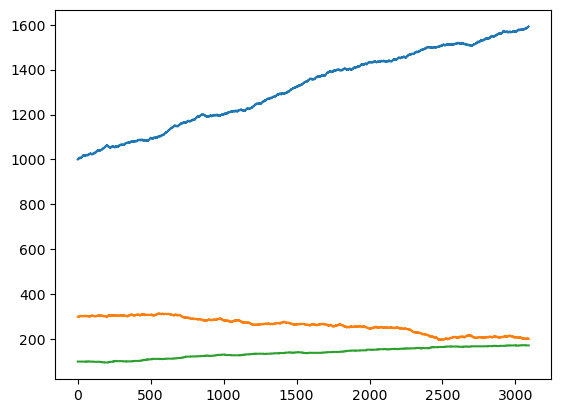

In [18]:
plt.plot(t)